<a href="https://colab.research.google.com/github/HinnaNayab/DeepLearning/blob/Applied-AI/Tutorial_2_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris #the IRIS dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #for scaling
from sklearn.neural_network import MLPClassifier #for MLP
from sklearn.metrics import accuracy_score, classification_report

In [2]:
#loading Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Class names:", iris.target_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


In [3]:
#splitting into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [4]:
# utilizing standardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

First 5 scaled training samples:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


In [5]:
# MLP model, from tutorial with two hidden layers, each with 10 neurons.
#Activation fxn is RELU and Adam is the optimizer (Adam adapts the learning rate during training).
#An optimizer controls how the weights are updated using the gradients

model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test accuracy: 0.9666666666666667

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
# inspecting the model/training information

print("Number of layers (including input/output):", model.n_layers_)
print("Hidden-layer sizes:", model.hidden_layer_sizes)
print("Activation:", model.activation)
print("Number of iterations:", model.n_iter_)
print("Final training loss:", model.loss_)

Number of layers (including input/output): 4
Hidden-layer sizes: (10, 10)
Activation: relu
Number of iterations: 500
Final training loss: 0.07198800042507271


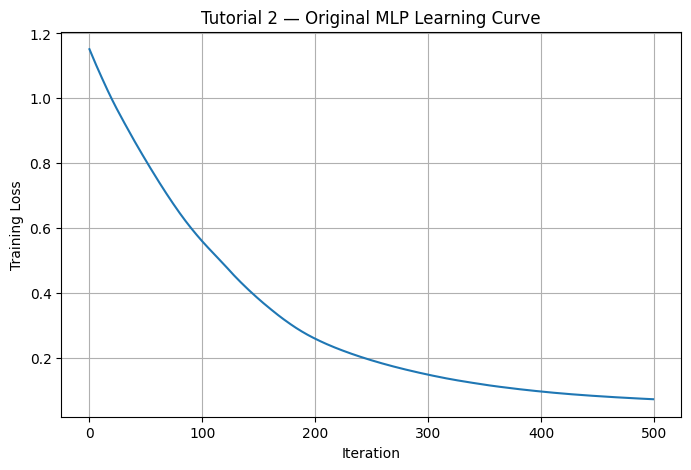

In [7]:
# plotting the learning curve (training loss vs iteration)

plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Tutorial 2 — Original MLP Learning Curve")
plt.grid(True)
plt.show()

In [8]:
# TASK 1A: Comparing architectures with different hidden layers and neurons configurations

architectures = {
    "1 hidden layer - 5 neurons": (5,),
    "1 hidden layer - 10 neurons": (10,),
    "2 hidden layers - 10,10 neurons": (10, 10),
    "2 hidden layers - 20,10 neurons": (20, 10),
    "3 hidden layers - 20,10,5 neurons": (20, 10, 5)
}

architecture_results = []

for name, architecture in architectures.items():
    m = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )

    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)

    architecture_results.append({
        "Architecture": name,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Iterations": m.n_iter_,
        "Final Training Loss": m.loss_
    })

architecture_results_df = pd.DataFrame(architecture_results)
display(architecture_results_df.sort_values("Test Accuracy", ascending=False))

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Architecture,Test Accuracy,Iterations,Final Training Loss
1,1 hidden layer - 10 neurons,0.966667,500,0.178749
3,"2 hidden layers - 20,10 neurons",0.966667,500,0.045540
2,"2 hidden layers - 10,10 neurons",0.966667,500,0.071988
4,"3 hidden layers - 20,10,5 neurons",0.966667,500,0.042741
0,1 hidden layer - 5 neurons,0.933333,500,0.266209


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


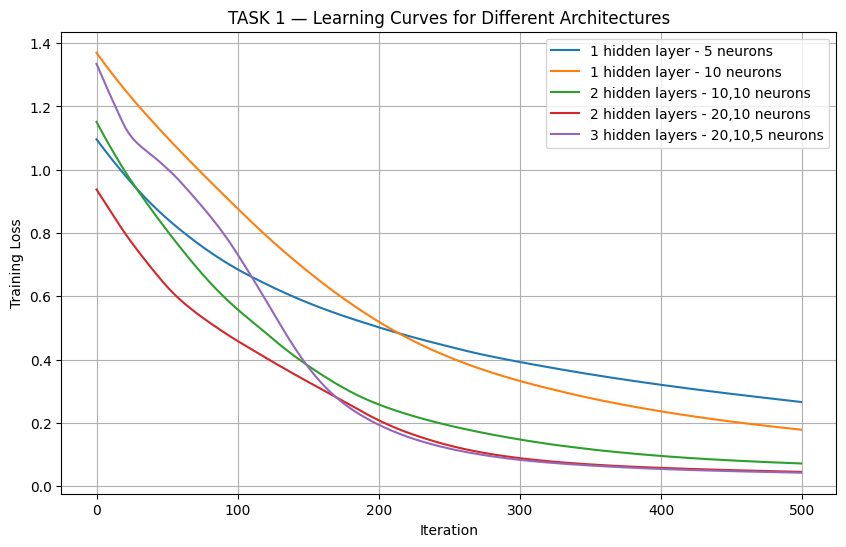

In [9]:
# TASK 1B: plotting the learning curves for the architectures

plt.figure(figsize=(10, 6))

for name, architecture in architectures.items():
    m = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    )
    m.fit(X_train_scaled, y_train)
    plt.plot(m.loss_curve_, label=name)

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("TASK 1 — Learning Curves for Different Architectures")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# TASK 2: chanigng and comparing learning rates

learning_rates = [0.0001, 0.001, 0.01, 0.1]

lr_results = []

for lr in learning_rates:
    m = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation="relu",
        solver="adam",
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )

    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)

    lr_results.append({
        "Learning Rate": lr,
        "Test Accuracy": accuracy_score(y_test, pred),
        "Iterations": m.n_iter_,
        "Final Training Loss": m.loss_
    })

lr_results_df = pd.DataFrame(lr_results)
display(lr_results_df)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Learning Rate,Test Accuracy,Iterations,Final Training Loss
0,0.0001,0.566667,500,0.799066
1,0.0010,0.966667,500,0.071988
2,0.0100,1.000000,136,0.039371
3,0.1000,0.966667,75,0.036190


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


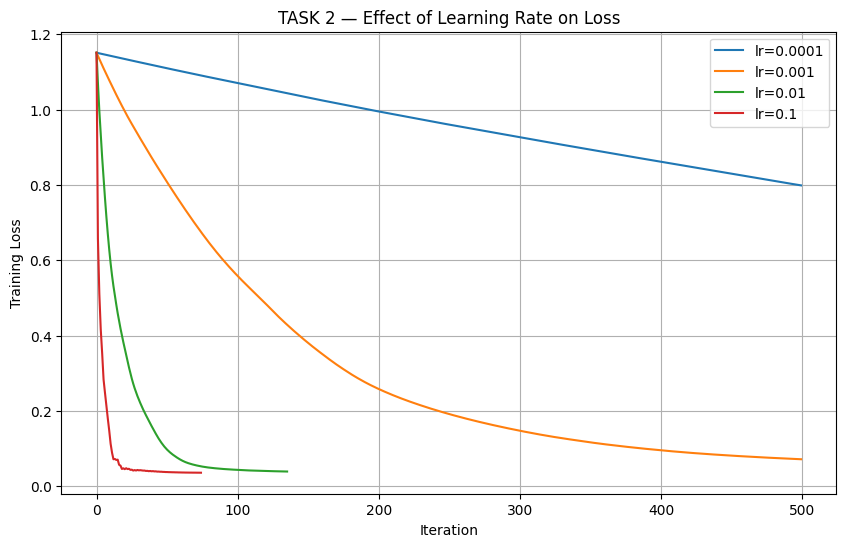

In [11]:
# TASK 2B: plotting loss curves for different learning rates

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    m = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation="relu",
        solver="adam",
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    m.fit(X_train_scaled, y_train)
    plt.plot(m.loss_curve_, label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("TASK 2 — Effect of Learning Rate on Loss")
plt.legend()
plt.grid(True)
plt.show()